<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/CostumerSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nmnbabbar/ecommerce-sales")

print("Path to dataset files:", path)

100%|██████████| 10.5k/10.5k [00:00<00:00, 5.46MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nmnbabbar/ecommerce-sales/versions/1


In [ ]:
import os

# List files in the downloaded path
files = os.listdir(path)
print("Files in the dataset directory:", files)

Files in the dataset directory: ['ecommerce_sales.csv']


In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, files[0])

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
print(df.head())

   OrderID        Date     Product     Category  Revenue Customer Location
0        1  2023-01-01       Phone  Electronics  1456.41               USA
1        2  2023-01-02  Headphones  Electronics   783.98             India
2        3  2023-01-03       Phone  Electronics  1295.32             India
3        4  2023-01-04       Phone  Accessories  1112.17             India
4        5  2023-01-05       Phone  Electronics   592.98                UK


In [ ]:
df


,OrderID,Date,Product,Category,Revenue,Customer Location
0,1,2023-01-01,Phone,Electronics,1456.41,USA
1,2,2023-01-02,Headphones,Electronics,783.98,India
2,3,2023-01-03,Phone,Electronics,1295.32,India
3,4,2023-01-04,Phone,Accessories,1112.17,India
4,5,2023-01-05,Phone,Electronics,592.98,UK
...,...,...,...,...,...,...
995,996,2025-09-22,Tablet,Electronics,616.17,USA
996,997,2025-09-23,Laptop,Accessories,1394.31,India
997,998,2025-09-24,Tablet,Electronics,1968.57,USA
998,999,2025-09-25,Laptop,Electronics,1182.97,USA


In [ ]:
df['Customer Location'].unique()

array(['USA', 'India', 'UK', 'Germany'], dtype=object)

In [ ]:
for col in df.columns:
    print(df[col].nunique())

1000
1000
4
2
994
4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrderID            1000 non-null   int64  
 1   Date               1000 non-null   object 
 2   Product            1000 non-null   object 
 3   Category           1000 non-null   object 
 4   Revenue            1000 non-null   float64
 5   Customer Location  1000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 47.0+ KB


por clustering de k-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [ ]:
df = df.drop(columns=['Customer Location'])

In [ ]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

In [ ]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

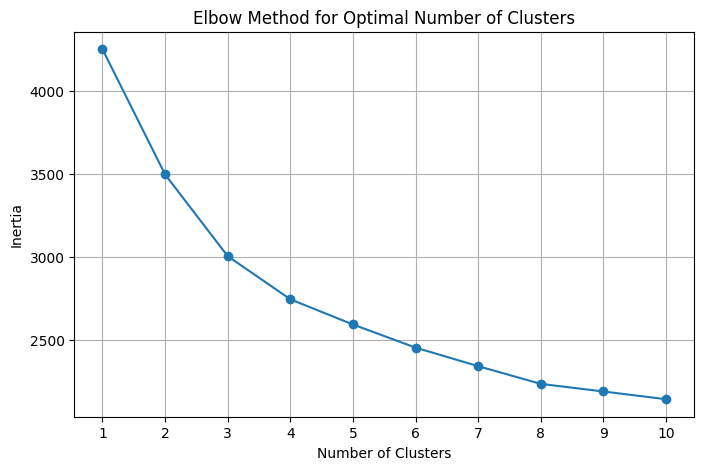

In [ ]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('kmeans', KMeans(random_state=42, n_init=10))]) # Added n_init to suppress warning

# Determine the optimal number of clusters using the elbow method
inertia = []
for n_clusters in range(1, 11):
    pipeline.set_params(kmeans__n_clusters=n_clusters)
    pipeline.fit(df)
    inertia.append(pipeline.named_steps['kmeans'].inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
optimal_n_clusters = 4
pipeline.set_params(kmeans__n_clusters=optimal_n_clusters)
pipeline.fit(df)

# Add the cluster labels to the original DataFrame
df['Cluster'] = pipeline.named_steps['kmeans'].labels_

# Display the first few rows with the new 'Cluster' column
display(df.head())

,OrderID,Date,Product,Category,Revenue,Cluster
0,1,2023-01-01,Phone,Electronics,1456.41,3
1,2,2023-01-02,Headphones,Electronics,783.98,0
2,3,2023-01-03,Phone,Electronics,1295.32,3
3,4,2023-01-04,Phone,Accessories,1112.17,3
4,5,2023-01-05,Phone,Electronics,592.98,0


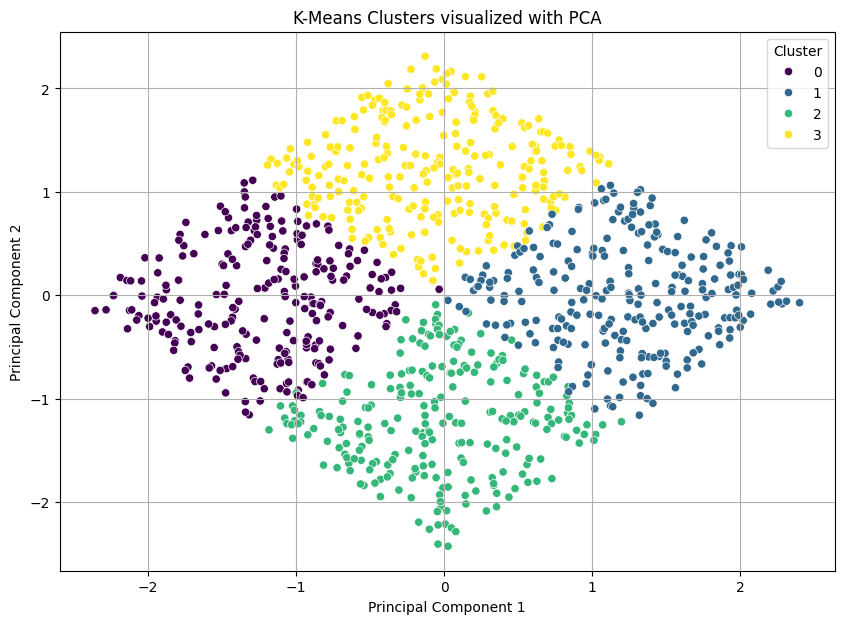

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
# We need to apply the preprocessing steps before PCA
X_preprocessed = pipeline.named_steps['preprocessor'].transform(df.drop(columns=['Cluster']))
X_pca = pca.fit_transform(X_preprocessed)

# Create a new DataFrame with PCA results and cluster labels
pca_df = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df['Cluster'] = df['Cluster']

# Visualize the clusters using a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='Cluster', data=pca_df, palette='viridis', legend='full')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

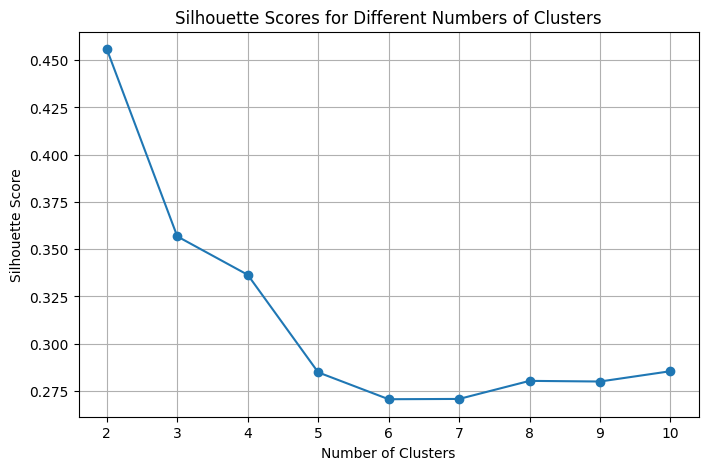

In [ ]:
silhouette_scores = []
for n_clusters in range(2, 11): # Silhouette score is not defined for n_clusters = 1
    pipeline.set_params(kmeans__n_clusters=n_clusters)
    pipeline.fit(df.drop(columns=['Cluster'])) # Fit on data without the added 'Cluster' column
    score = silhouette_score(pipeline.transform(df.drop(columns=['Cluster'])), pipeline.named_steps['kmeans'].labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [ ]:
print("Cluster sizes:")
print(df['Cluster'].value_counts())

print("\nMean values of numerical features by cluster:")
display(df.groupby('Cluster')[numerical_features].mean())

print("\nDistribution of categorical features by cluster:")
for col in categorical_features:
    print(f"\nDistribution of {col} by cluster:")
    display(df.groupby('Cluster')[col].value_counts(normalize=True).unstack().fillna(0))

Cluster sizes:
Cluster
3    257
1    257
2    247
0    239
Name: count, dtype: int64

Mean values of numerical features by cluster:


,OrderID,Revenue
Cluster,,
0,257.058577,534.459833
1,757.505837,1517.815292
2,738.781377,537.307045
3,240.875486,1505.276887



Distribution of categorical features by cluster:

Distribution of Date by cluster:


Date,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,...,2025-09-17,2025-09-18,2025-09-19,2025-09-20,2025-09-21,2025-09-22,2025-09-23,2025-09-24,2025-09-25,2025-09-26
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.004184,0.000000,0.000000,0.004184,0.000000,0.000000,0.004184,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.003891,0.000000,0.003891,0.003891,0.000000,0.003891,0.003891,0.003891,0.003891
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004049,0.000000,0.004049,0.000000,0.000000,0.004049,0.000000,0.000000,0.000000,0.000000
3,0.003891,0.000000,0.003891,0.003891,0.000000,0.003891,0.003891,0.000000,0.003891,0.003891,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Distribution of Product by cluster:


Product,Headphones,Laptop,Phone,Tablet
Cluster,,,,
0,0.238494,0.213389,0.301255,0.246862
1,0.311284,0.206226,0.233463,0.249027
2,0.226721,0.230769,0.267206,0.275304
3,0.260700,0.276265,0.225681,0.237354



Distribution of Category by cluster:


Category,Accessories,Electronics
Cluster,,
0,0.535565,0.464435
1,0.548638,0.451362
2,0.417004,0.582996
3,0.533074,0.466926
